In [1]:
# classification se regression

In [4]:
# load the data set
import pandas as pd
import matplotlib.pyplot as plt

# Dataset load karo (Sahi URL)
url = "https://raw.githubusercontent.com/selva86/datasets/master/Admission.csv"

df = pd.read_csv(url)

# First 5 rows
df.head()


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
# lets inspect the dataset
print(df.shape)
print(df.columns)

(400, 9)
Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')


In [6]:
# understand the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [7]:
# statistics
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [8]:
# missing values
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [9]:
# serial no ki zaraota nahi to ise drop karte ha
# Serial number prediction ke liye useful nahi
df = df.drop('Serial No.', axis=1)

In [10]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [11]:
# lets separate the input and the output
X = df.drop('Chance of Admit ', axis=1)

y = df['Chance of Admit ']

In [12]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [13]:
y

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65
...,...
395,0.82
396,0.84
397,0.91
398,0.67


In [24]:
# lets visualize the data
# cgpa vs admission chance
df.columns = df.columns.str.strip()

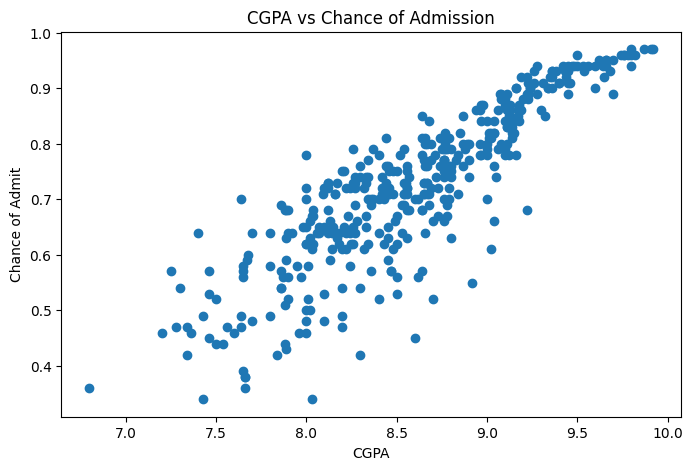

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['CGPA'],
    df['Chance of Admit']
)

plt.xlabel("CGPA")
plt.ylabel("Chance of Admit")
plt.title("CGPA vs Chance of Admission")

plt.show()

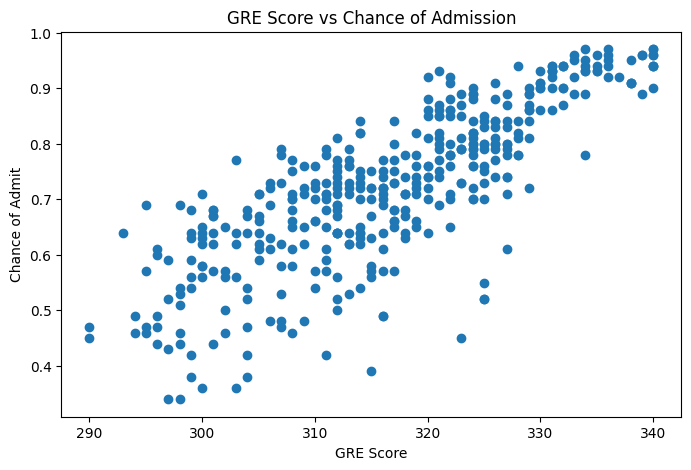

In [26]:
# gre vs admission chance
plt.figure(figsize=(8, 5))

plt.scatter(
    df['GRE Score'],
    df['Chance of Admit']
)

plt.xlabel("GRE Score")
plt.ylabel("Chance of Admit")
plt.title("GRE Score vs Chance of Admission")

plt.show()

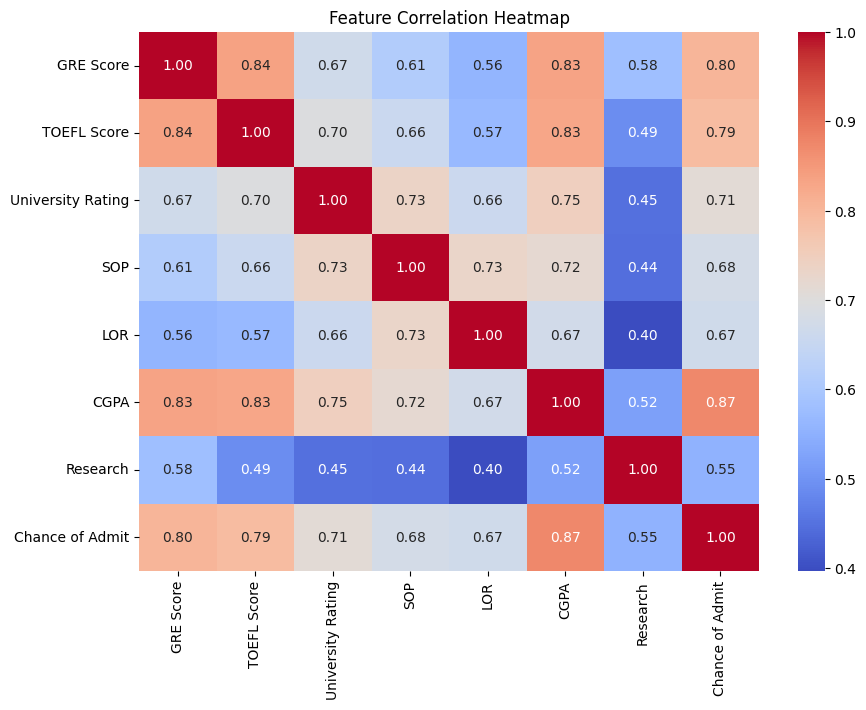

In [27]:
# co relation heatmap
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [28]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Training data se scaling parameters learn karo
X_train = scaler.fit_transform(X_train)

# Test data ko same parameters se transform karo
X_test = scaler.transform(X_test)

In [30]:
# ann architecture
import tensorflow as tf

model = tf.keras.Sequential([

    # First hidden layer
    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    # Second hidden layer
    tf.keras.layers.Dense(
        8,
        activation='relu'
    ),

    # Output layer
    # Regression → one continuous value
    tf.keras.layers.Dense(1)
])

In [31]:
# Input Features
#       ↓
# Dense(16)
# ReLU
#       ↓
# Dense(8)
# ReLU
#       ↓
# Dense(1)
# Linear
#       ↓
# Chance of Admit

In [32]:
# compile
model.compile(

    # Weights update karega
    optimizer='adam',

    # Regression loss
    loss='mse',

    # MAE bhi track karenge
    metrics=['mae']
)

In [33]:
# train
history = model.fit(

    X_train,
    y_train,

    # Training repetitions
    epochs=100,

    # Samples per batch
    batch_size=32,

    # Training data ka 20% validation
    validation_split=0.2,

    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.3622 - mae: 0.5483 - val_loss: 0.2619 - val_mae: 0.4481
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2658 - mae: 0.4600 - val_loss: 0.1884 - val_mae: 0.3786
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2039 - mae: 0.3925 - val_loss: 0.1420 - val_mae: 0.3228
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1592 - mae: 0.3388 - val_loss: 0.1057 - val_mae: 0.2734
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1226 - mae: 0.2895 - val_loss: 0.0820 - val_mae: 0.2361
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0987 - mae: 0.2594 - val_loss: 0.0693 - val_mae: 0.2133
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0811 - mae: 0.2364 - val_loss: 0.0626 - val_mae: 0.1996
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0694 - mae: 0.2179 - val_loss: 0.0575 - val_mae: 0.1875
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0609 - mae: 

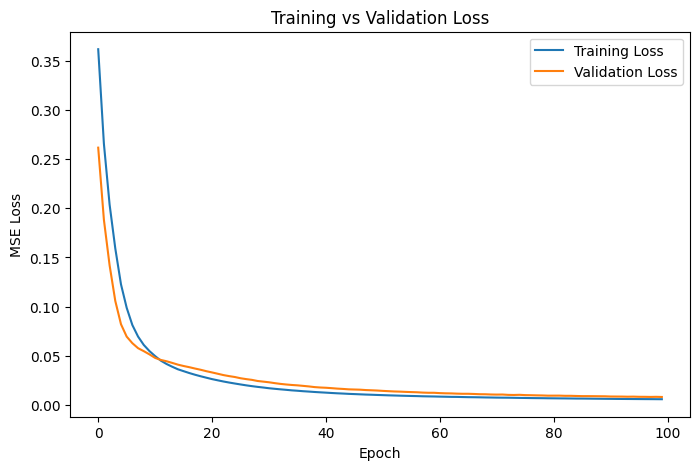

In [34]:
# loss graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

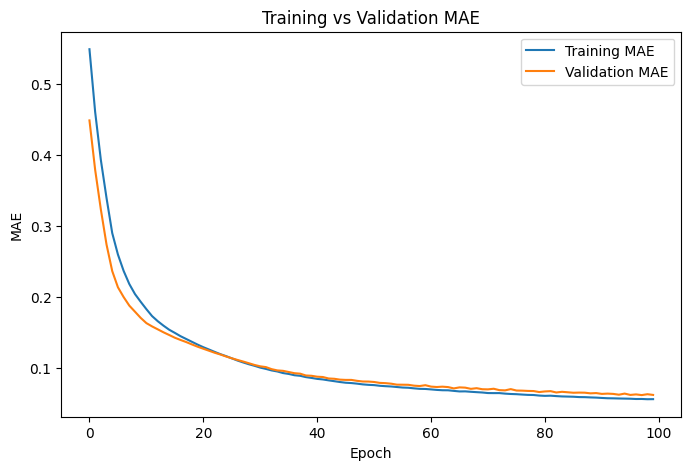

In [35]:
# mae graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['mae'],
    label='Training MAE'
)

plt.plot(
    history.history['val_mae'],
    label='Validation MAE'
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.show()

In [36]:
# test set evaluation
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.007458028383553028
Test MAE: 0.06025935336947441


In [37]:
# predictions
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


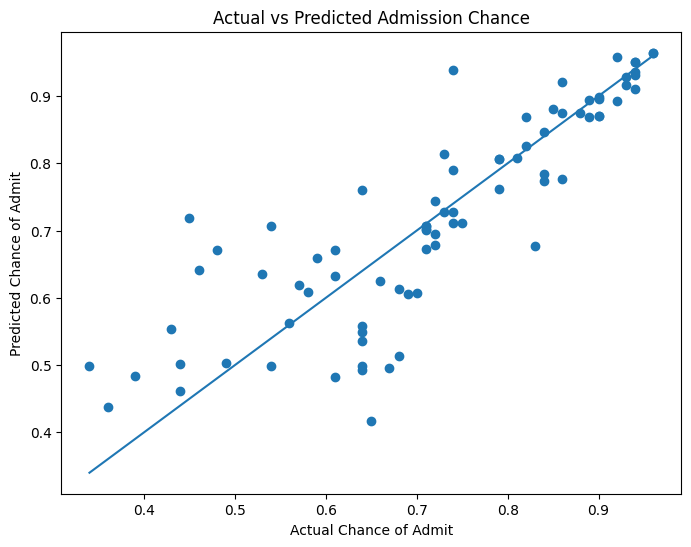

In [38]:
# actual vs prediction ka graph
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")

plt.title("Actual vs Predicted Admission Chance")

plt.show()

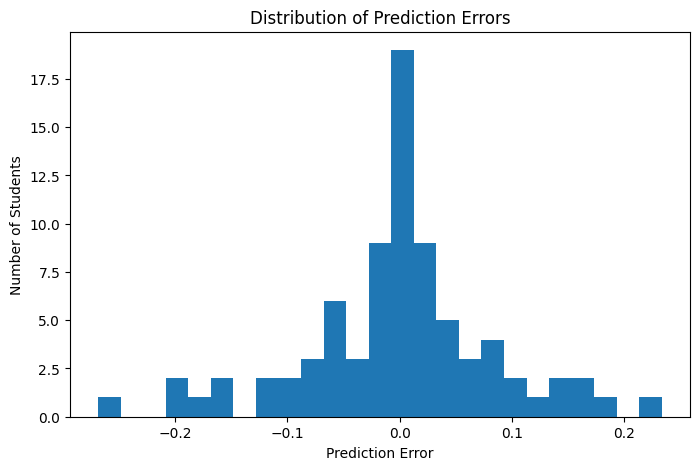

In [39]:
# prediction error
errors = y_test.values - y_pred.flatten()

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=25
)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Students")
plt.title("Distribution of Prediction Errors")

plt.show()

In [40]:
# individual student prediction
student = [[
    320,    # GRE Score
    110,    # TOEFL Score
    4,      # University Rating
    4.0,    # SOP
    4.0,    # LOR
    9.0,    # CGPA
    1       # Research
]]

In [41]:
student_scaled = scaler.transform(student)

prediction = model.predict(student_scaled)

print(
    "Predicted Chance of Admission:",
    prediction[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Chance of Admission: 0.86270213


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [42]:
# GRADUATE DATA
#      ↓
# Preprocessing
#      ↓
# Scaling
#      ↓
#        ANN
#         │
#    ┌────┴────┐
#    ↓         ↓
# Hidden    Hidden
# Layer     Layer
#    ↓         ↓
#    └────┬────┘
#         ↓
#      Dense(1)
#       Linear
#         ↓
# Chance of Admit
#         ↓
#        MSE
#         ↓
#  Backpropagation
#         ↓
#       Adam
#         ↓
#  Weight Update